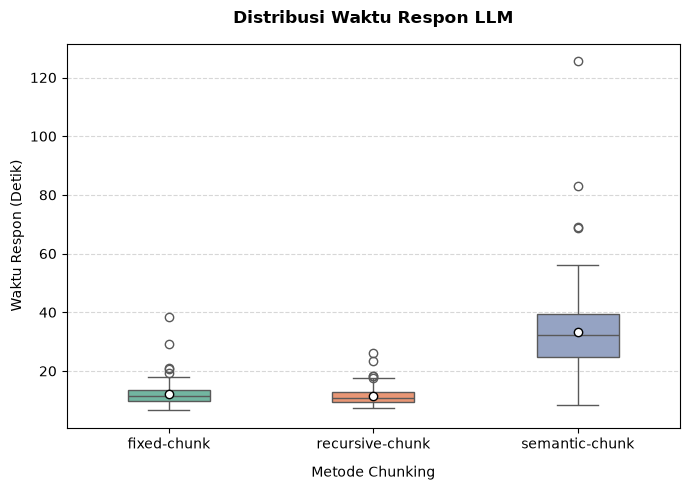

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_results = pd.read_csv(r"..\result_data\result_data.csv", sep=";")
data = df_results.filter(like="duration_response").copy()

clean_columns = {col: col.replace("_duration_response", "") for col in data.columns}
data.rename(columns=clean_columns, inplace=True)

# 4. Plot Boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=data,
    palette="Set2",
    width=0.4,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "6",
    },
)

plt.title(
    "Distribusi Waktu Respon LLM",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Metode Chunking", fontsize=10, labelpad=10)
plt.ylabel("Waktu Respon (Detik)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

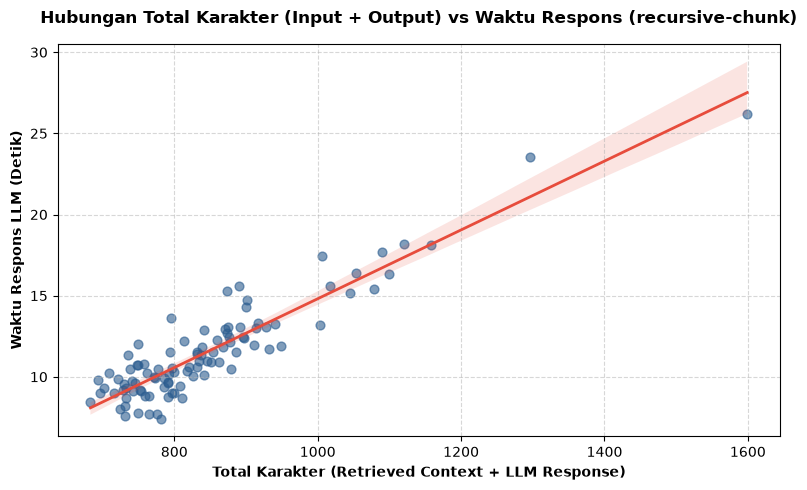

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

collection_name = "semantic-chunk"
context_col = f"{collection_name}_retrieved_context"
response_text_col = f"{collection_name}_llm_response"
response_time_col = f"{collection_name}_duration_response"

columns = [context_col, response_text_col, response_time_col]

df_results = pd.read_csv(r"..\result_data\result_data.csv", sep=";")
data = df_results[columns].copy()

data["context_char"] = data[context_col].astype(str).str.len()
data["response_char"] = data[response_text_col].astype(str).str.len()

data["total_char"] = data["context_char"] + data["response_char"]

plt.figure(figsize=(8, 5))
sns.regplot(
  data=data,
  x="total_char",
  y=response_time_col,
  color="#2b5c8f",
  scatter_kws={"alpha": 0.6, "s": 40},
  line_kws={"color": "#e74c3c", "linewidth": 2},
)

plt.title(
  f"Hubungan Total Karakter (Input + Output) vs Waktu Respons ({collection_name})",
  fontsize=12,
  fontweight="bold",
  pad=15,
)
plt.xlabel(
  "Total Karakter (Retrieved Context + LLM Response)",
  fontsize=10,
  fontweight="bold",
)
plt.ylabel("Waktu Respons LLM (Detik)", fontsize=10, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()